# SparseGPT + LASS — OPT-1.3B


In [ ]:


import os, gc, json, math, copy, shutil
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


@dataclass
class PruneConfig:
    model_name: str               = "facebook/opt-1.3b"
    sparsity_ratio: float         = 0.30
    lass_min_sparsity: float      = 0.20
    lass_max_sparsity: float      = 0.45
    # OPT-1.3B is ~2.6GB in float16; keep samples low to avoid OOM
    lass_sensitivity_samples: int = 8
    n_calibration_samples: int    = 64
    calibration_seqlen: int       = 512
    blocksize: int                = 128
    percdamp: float               = 0.01

cfg = PruneConfig()

OUTPUT_UNIFORM = "/kaggle/working/opt_pruned_uniform"
OUTPUT_LASS    = "/kaggle/working/opt_pruned_lass"
os.makedirs(OUTPUT_UNIFORM, exist_ok=True)
os.makedirs(OUTPUT_LASS,    exist_ok=True)



def load_model():
    tok = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        cfg.model_name,
        dtype=torch.float16,   # half precision → halves GPU RAM
        low_cpu_mem_usage=True,
    )
    mdl.eval()
    for p in mdl.parameters():
        p.requires_grad = False
    return mdl, tok

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token



def get_calibration_data(nsamples, seqlen, tokenizer, seed=0):
    ds = load_dataset(
        "allenai/c4",
        data_files={"train": "en/c4-train.00000-of-01024.json.gz"},
        split="train",
    )
    rng = np.random.default_rng(seed)
    samples, attempts = [], 0
    pbar = tqdm(total=nsamples, desc="Calibration samples")
    while len(samples) < nsamples and attempts < nsamples * 300:
        idx = int(rng.integers(0, len(ds)))
        enc = tokenizer(ds[idx]["text"], return_tensors="pt", add_special_tokens=False)
        if enc.input_ids.shape[1] >= seqlen:
            start = int(rng.integers(0, enc.input_ids.shape[1] - seqlen + 1))
            samples.append(enc.input_ids[:, start:start + seqlen])
            pbar.update(1)
        attempts += 1
    pbar.close()
    return samples

print(f"Collecting {cfg.n_calibration_samples} calibration samples...")
calib_samples = get_calibration_data(cfg.n_calibration_samples, cfg.calibration_seqlen, tokenizer)
print(f"Got {len(calib_samples)} samples ✓")



class SparseGPT:
    def __init__(self, layer: nn.Linear):
        self.layer   = layer
        self.rows    = layer.weight.shape[0]
        self.columns = layer.weight.shape[1]
        self.dev     = layer.weight.device
        self.H       = torch.zeros((self.columns, self.columns),
                                   device=self.dev, dtype=torch.float32)
        self.nsamples = 0

    def add_batch(self, inp: torch.Tensor):
        if inp.dim() > 2:
            inp = inp.reshape(-1, inp.shape[-1])
        inp = inp.to(self.dev, dtype=torch.float32)
        bs  = inp.shape[0]
        self.H       *= self.nsamples / (self.nsamples + bs)
        self.nsamples += bs
        inp            = inp * math.sqrt(2.0 / self.nsamples)
        self.H        += inp.t() @ inp

    def prune(self, sparsity: float, blocksize: int = 128, percdamp: float = 0.01):
        W    = self.layer.weight.data.clone().float()
        H    = self.H.clone()
        dead = torch.diag(H) == 0
        H[dead, dead] = 1.0
        W[:, dead]    = 0.0

        damp     = percdamp * torch.mean(torch.diag(H))
        diag_idx = torch.arange(self.columns, device=self.dev)
        H[diag_idx, diag_idx] += damp

        H    = torch.linalg.cholesky(H)
        H    = torch.cholesky_inverse(H)
        H    = torch.linalg.cholesky(H, upper=True)
        Hinv = H

        mask = torch.zeros_like(W, dtype=torch.bool)

        for i1 in range(0, self.columns, blocksize):
            i2    = min(i1 + blocksize, self.columns)
            count = i2 - i1
            W1    = W[:, i1:i2].clone()
            Q1    = torch.zeros_like(W1)
            Err1  = torch.zeros_like(W1)
            mask1 = torch.zeros_like(W1, dtype=torch.bool)
            Hinv1 = Hinv[i1:i2, i1:i2]

            if sparsity > 0:
                scores = (W1 ** 2) / (torch.diag(Hinv1).reshape(1, -1) ** 2 + 1e-8)
                k      = max(1, int(scores.numel() * sparsity))
                thresh = torch.sort(scores.flatten())[0][k - 1]
                mask1  = scores <= thresh

            for j in range(count):
                w = W1[:, j]
                d = Hinv1[j, j]
                q = w.clone()
                q[mask1[:, j]] = 0
                Q1[:, j] = q
                err = (w - q) / (d + 1e-8)
                W1[:, j:] -= err.unsqueeze(1) * Hinv1[j, j:].unsqueeze(0)
                Err1[:, j] = err

            W[:, i1:i2]   = Q1
            mask[:, i1:i2] = mask1
            W[:, i2:]     -= Err1 @ Hinv[i1:i2, i2:]

        self.layer.weight.data = W.to(self.layer.weight.dtype)
        return mask

    def free(self):
        self.H = None
        if self.dev.type == "cuda":
            torch.cuda.empty_cache()


def find_linears(module):
    return {n: m for n, m in module.named_modules() if isinstance(m, nn.Linear)}



def get_opt_layers(model):
    """Return the decoder layer list for OPT."""
    return model.model.decoder.layers


def capture_layer_inputs_opt(model, calib_samples, n_samples=None):
    """
    Capture inputs to the first decoder layer.
    OPT's forward: embed_tokens + embed_positions → layers[0] → ...
    We intercept at layers[0] with a Catcher module.
    """
    layers      = get_opt_layers(model)
    n           = n_samples or len(calib_samples)
    dtype       = next(iter(model.parameters())).dtype
    hidden_size = model.config.hidden_size
    seqlen      = calib_samples[0].shape[1]

    inps  = torch.zeros((n, seqlen, hidden_size), dtype=dtype, device=DEVICE)
    cache = {"i": 0, "kw": {}}

    class Catcher(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.module = m
        def forward(self, h, **kw):
            inps[cache["i"]] = h
            cache["i"]      += 1
            cache["kw"]      = kw
            raise ValueError
        def __getattr__(self, name):
            try:
                return super().__getattr__(name)
            except AttributeError:
                return getattr(self.module, name)

    # Move OPT embedding components to DEVICE
    model.model.decoder.embed_tokens.to(DEVICE)
    model.model.decoder.embed_positions.to(DEVICE)
    if hasattr(model.model.decoder, 'project_in') and model.model.decoder.project_in is not None:
        model.model.decoder.project_in.to(DEVICE)

    layers[0] = Catcher(layers[0])
    for s in calib_samples[:n]:
        try:
            model(s.to(DEVICE))
        except ValueError:
            pass
    layers[0] = layers[0].module

    # Move embeddings back to CPU
    model.model.decoder.embed_tokens.cpu()
    model.model.decoder.embed_positions.cpu()
    if hasattr(model.model.decoder, 'project_in') and model.model.decoder.project_in is not None:
        model.model.decoder.project_in.cpu()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return inps, cache["kw"]



def compute_lass_budgets(model, calib_samples, cfg):
    print("\n[LASS] Running sensitivity pre-scan...")
    layers   = get_opt_layers(model)
    n_scan   = min(cfg.lass_sensitivity_samples, len(calib_samples))
    inps, kw = capture_layer_inputs_opt(model, calib_samples, n_scan)
    outs     = torch.zeros_like(inps)

    sensitivities = []

    for idx in tqdm(range(len(layers)), desc="LASS sensitivity scan"):
        layer  = layers[idx].to(DEVICE)
        subset = find_linears(layer)

        gpts    = {n: SparseGPT(lin) for n, lin in subset.items()}
        handles = []
        def make_hook(name):
            def h(_, inp, __): gpts[name].add_batch(inp[0].data)
            return h
        for n, lin in subset.items():
            handles.append(lin.register_forward_hook(make_hook(n)))
        with torch.no_grad():
            for j in range(n_scan):
                layer(inps[j].unsqueeze(0), **kw)
        for h in handles:
            h.remove()

        sample_in = inps[0].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            out_orig = layer(sample_in, **kw)[0].clone()

        errors = []
        for n, gpt in gpts.items():
            W_orig = gpt.layer.weight.data.clone()

            gpt_copy = copy.deepcopy(gpt)
            gpt_copy.prune(cfg.sparsity_ratio,
                           blocksize=cfg.blocksize,
                           percdamp=cfg.percdamp)
            gpt.layer.weight.data.copy_(gpt_copy.layer.weight.data)

            with torch.no_grad():
                out_pruned = layer(sample_in, **kw)[0].clone()

            err = (out_orig - out_pruned).norm().item() / \
                  (out_orig.norm().item() + 1e-9)
            errors.append(err)

            gpt.layer.weight.data.copy_(W_orig)
            gpt.free()
            del gpt_copy

        sensitivities.append(float(np.mean(errors)))

        with torch.no_grad():
            for j in range(n_scan):
                outs[j] = layer(inps[j].unsqueeze(0), **kw)[0].squeeze(0)

        layers[idx] = layer.cpu()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        inps, outs = outs, inps

    sens_arr = np.array(sensitivities)
    print(f"\n[LASS] Raw sensitivities: min={sens_arr.min():.4f} "
          f"max={sens_arr.max():.4f} mean={sens_arr.mean():.4f}")

    if sens_arr.max() < 1e-8:
        print("[LASS] WARNING: all sensitivities zero — using uniform fallback")
        n = len(layers)
        return ({i: cfg.sparsity_ratio for i in range(n)},
                sensitivities,
                [cfg.sparsity_ratio] * n)

    inv_sens = 1.0 / (sens_arr + 1e-6)
    inv_norm = inv_sens / inv_sens.mean()

    param_counts = np.array([
        sum(p.numel() for p in layers[i].parameters())
        for i in range(len(layers))
    ])

    raw     = cfg.sparsity_ratio * inv_norm
    raw     = np.clip(raw, cfg.lass_min_sparsity, cfg.lass_max_sparsity)
    w_mean  = np.sum(raw * param_counts) / np.sum(param_counts)
    scale   = cfg.sparsity_ratio / w_mean
    adapted = np.clip(raw * scale, cfg.lass_min_sparsity, cfg.lass_max_sparsity)

    budgets = {i: float(adapted[i]) for i in range(len(layers))}

    print(f"[LASS] Adapted range : [{adapted.min():.3f}, {adapted.max():.3f}]")
    print(f"[LASS] Weighted mean : "
          f"{np.sum(adapted * param_counts) / np.sum(param_counts):.4f} "
          f"(target={cfg.sparsity_ratio})")

    return budgets, sensitivities, adapted.tolist()



def prune_model(model, calib_samples, cfg, layer_budgets, label=""):
    layers = get_opt_layers(model)
    model.config.use_cache = False

    print(f"\nCapturing layer inputs for [{label}]...")
    inps, kw = capture_layer_inputs_opt(model, calib_samples)
    outs      = torch.zeros_like(inps)

    all_masks, per_layer_stats = {}, []

    for idx in tqdm(range(len(layers)), desc=f"Pruning [{label}]"):
        layer  = layers[idx].to(DEVICE)
        subset = find_linears(layer)
        gpts   = {n: SparseGPT(lin) for n, lin in subset.items()}

        handles = []
        def make_hook(name):
            def h(_, inp, __): gpts[name].add_batch(inp[0].data)
            return h
        for n, lin in subset.items():
            handles.append(lin.register_forward_hook(make_hook(n)))
        for j in range(len(calib_samples)):
            layer(inps[j].unsqueeze(0), **kw)
        for h in handles:
            h.remove()

        budget = layer_budgets[idx]
        stats  = {"layer": idx, "budget": budget, "sublayers": {}}

        for n, gpt in gpts.items():
            mask   = gpt.prune(budget, blocksize=cfg.blocksize,
                               percdamp=cfg.percdamp)
            actual = mask.float().mean().item()
            stats["sublayers"][n] = actual
            all_masks[f"layer.{idx}.{n}"] = mask.cpu()
            gpt.free()

        with torch.no_grad():
            for j in range(len(calib_samples)):
                outs[j] = layer(inps[j].unsqueeze(0), **kw)[0].squeeze(0)

        layers[idx] = layer.cpu()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        inps, outs = outs, inps
        per_layer_stats.append(stats)

    model.config.use_cache = True
    return all_masks, per_layer_stats



def evaluate_ppl(model, tokenizer, seqlen=512, n_chunks=40):
    model = model.to(DEVICE)
    model.eval()
    data = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    enc  = tokenizer("\n\n".join(data["text"]), return_tensors="pt").input_ids

    nlls = []
    with torch.no_grad():
        for i in range(min(n_chunks, enc.shape[1] // seqlen)):
            batch = enc[:, i * seqlen:(i + 1) * seqlen].to(DEVICE)
            loss  = model(batch, labels=batch).loss.float()
            nlls.append(loss * (seqlen - 1))

    ppl = torch.exp(torch.stack(nlls).sum() / (len(nlls) * (seqlen - 1)))
    model.cpu()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return ppl.item()


def compute_sparsity(model):
    total, zeros = 0, 0
    for n, p in model.named_parameters():
        if "weight" in n and p.dim() >= 2:
            total += p.numel()
            zeros += (p == 0).sum().item()
    return 100.0 * zeros / total if total > 0 else 0.0



print("\n" + "="*55)
print("  RUN 1: Uniform SparseGPT (no LASS) — baseline")
print("="*55)

model_uniform, _ = load_model()
n_layers         = len(get_opt_layers(model_uniform))
uniform_budgets  = {i: cfg.sparsity_ratio for i in range(n_layers)}

masks_uniform, stats_uniform = prune_model(
    model_uniform, calib_samples, cfg, uniform_budgets, label="Uniform"
)

print("\nEvaluating Uniform SparseGPT PPL...")
ppl_uniform  = evaluate_ppl(model_uniform, tokenizer)
spar_uniform = compute_sparsity(model_uniform)
print(f"  Sparsity : {spar_uniform:.2f}%")
print(f"  PPL      : {ppl_uniform:.2f}")

model_uniform.save_pretrained(OUTPUT_UNIFORM)
tokenizer.save_pretrained(OUTPUT_UNIFORM)
print(f"  Saved to : {OUTPUT_UNIFORM}")

del model_uniform
gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()



print("\n" + "="*55)
print("  RUN 2: SparseGPT + LASS (our novelty)")
print("="*55)

model_lass, _ = load_model()

lass_budgets, lass_sensitivities, lass_adapted = compute_lass_budgets(
    model_lass, calib_samples, cfg
)

print("\nPer-layer LASS budgets:")
for i, (s, sens) in enumerate(zip(lass_adapted, lass_sensitivities)):
    bar = "█" * int(s * 30)
    tag = "↓ protected" if s < cfg.sparsity_ratio else "↑ pruned more"
    print(f"  Layer {i:2d}: {s:.3f}  sens={sens:.4f}  {bar}  {tag}")

masks_lass, stats_lass = prune_model(
    model_lass, calib_samples, cfg, lass_budgets, label="LASS"
)

print("\nEvaluating LASS PPL...")
ppl_lass  = evaluate_ppl(model_lass, tokenizer)
spar_lass = compute_sparsity(model_lass)
print(f"  Sparsity : {spar_lass:.2f}%")
print(f"  PPL      : {ppl_lass:.2f}")

model_lass.save_pretrained(OUTPUT_LASS)
tokenizer.save_pretrained(OUTPUT_LASS)
print(f"  Saved to : {OUTPUT_LASS}")

del model_lass
gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()



print("\nEvaluating original model PPL...")
model_orig, _ = load_model()
ppl_orig      = evaluate_ppl(model_orig, tokenizer)
print(f"  PPL (original): {ppl_orig:.2f}")
del model_orig
gc.collect()



inc_u = (ppl_uniform - ppl_orig) / ppl_orig * 100
inc_l = (ppl_lass    - ppl_orig) / ppl_orig * 100
lass_improvement = ppl_uniform - ppl_lass

print("\n\n" + "="*62)
print("       ABLATION STUDY: SparseGPT vs LASS — OPT-1.3B")
print("="*62)
print(f"{'Model':<30} {'Sparsity':>10} {'PPL':>8} {'Δ PPL':>10}")
print("-"*62)
print(f"{'Original (dense)':<30} {'0.00%':>10} {ppl_orig:>8.2f} {'—':>10}")
print(f"{'Uniform SparseGPT':<30} {spar_uniform:>9.2f}% {ppl_uniform:>8.2f} {inc_u:>+9.1f}%")
print(f"{'SparseGPT + LASS (ours)':<30} {spar_lass:>9.2f}% {ppl_lass:>8.2f} {inc_l:>+9.1f}%")
print("="*62)
print(f"\nLASS improvement over uniform: {lass_improvement:.2f} PPL points")
print(f"(Lower is better — LASS should win here)")



fig, axes = plt.subplots(1, 3, figsize=(16, 4))
n         = len(lass_sensitivities)
layer_ids = list(range(n))

axes[0].bar(layer_ids, lass_sensitivities, color="steelblue", alpha=0.8)
axes[0].axhline(np.mean(lass_sensitivities), color="red", ls="--", label="mean")
axes[0].set_title("Per-layer Sensitivity (LASS scan) — OPT-1.3B")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Output reconstruction error")
axes[0].legend()

axes[1].bar(layer_ids, lass_adapted,
            color=["green" if s < cfg.sparsity_ratio else "orange"
                   for s in lass_adapted], alpha=0.8)
axes[1].axhline(cfg.sparsity_ratio, color="red", ls="--",
                label=f"uniform={cfg.sparsity_ratio}")
axes[1].set_title("LASS Adapted Sparsity per Layer")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Sparsity budget")
axes[1].legend()

models_ = ["Original", "Uniform\nSparseGPT", "SparseGPT\n+LASS (ours)"]
ppls_   = [ppl_orig, ppl_uniform, ppl_lass]
colors_ = ["#2196F3", "#FF5722", "#4CAF50"]
bars    = axes[2].bar(models_, ppls_, color=colors_, alpha=0.85, width=0.5)
axes[2].set_title("Perplexity Comparison (↓ better)")
axes[2].set_ylabel("Perplexity")
for bar, val in zip(bars, ppls_):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/opt_lass_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved: /kaggle/working/opt_lass_ablation.png")



summary = {
    "model"                    : cfg.model_name,
    "target_sparsity"          : cfg.sparsity_ratio,
    "ppl_original"             : round(ppl_orig, 3),
    "ppl_uniform"              : round(ppl_uniform, 3),
    "ppl_lass"                 : round(ppl_lass, 3),
    "sparsity_uniform"         : round(spar_uniform, 3),
    "sparsity_lass"            : round(spar_lass, 3),
    "lass_improvement_ppl"     : round(lass_improvement, 3),
    "ppl_increase_uniform_pct" : round(inc_u, 2),
    "ppl_increase_lass_pct"    : round(inc_l, 2),
    "lass_per_layer_budgets"   : lass_budgets,
    "lass_sensitivities"       : lass_sensitivities,
}
with open("/kaggle/working/opt_ablation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Summary saved: /kaggle/working/opt_ablation_summary.json")



shutil.make_archive("/kaggle/working/opt_pruned_lass_model",    "zip", OUTPUT_LASS)
shutil.make_archive("/kaggle/working/opt_pruned_uniform_model", "zip", OUTPUT_UNIFORM)
print("Zips ready in Kaggle Output panel.")
print(f"\n>>> Next step: use OUTPUT_LASS as input to your KD notebook")
print(f"    Path: {OUTPUT_LASS}")
print("\nDONE ✓")

## Cell 2 — Masked Knowledge Distillation (OPT-1.3B)

In [ ]:
import os as _os, packaging.version as _pv, torch as _tv
if _pv.parse(_tv.__version__) < _pv.parse("2.6.0"):
    _os.environ["TRANSFORMERS_WEIGHTS_ONLY"] = "0"


import os, gc
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from safetensors.torch import save_file

device = "cuda:0" if torch.cuda.is_available() else "cpu"

PRUNED_PATH = "/kaggle/working/opt_pruned_lass"
SAVE_PATH   = "/kaggle/working/opt_final_sparse_kd"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(PRUNED_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


print("Loading student (float16, cuda:0)...")
student = AutoModelForCausalLM.from_pretrained(
    PRUNED_PATH,
    dtype=torch.float16,
).to(device)
student.train()


print("Loading teacher (CPU) — facebook/opt-1.3b...")
teacher = AutoModelForCausalLM.from_pretrained(
    "facebook/opt-1.3b",
    dtype=torch.float16,
).cpu()
teacher.eval()

gc.collect()
torch.cuda.empty_cache()
print(f"GPU free after loading: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")


try:
    import bitsandbytes as bnb
    optimizer = bnb.optim.AdamW8bit(student.parameters(), lr=2e-7)
    print("Optimizer: 8-bit AdamW ✓")
except (ImportError, AttributeError):
    optimizer = torch.optim.SGD(student.parameters(), lr=1e-6, momentum=0.0)
    print("Optimizer: SGD (no momentum buffers)")


print("Loading WikiText-2...")
hf_ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:500]")
hf_ds = hf_ds.filter(lambda x: len(x["text"].strip()) > 50)

def tokenize_fn(x):
    out = tokenizer(x["text"], truncation=True, max_length=64,
                    padding="max_length")
    out["labels"] = out["input_ids"].copy()
    return out

hf_ds = hf_ds.map(tokenize_fn)
print("Dataset ready:", len(hf_ds))


print("Deriving masks...")
masks = {}
for name, param in student.named_parameters():
    if "weight" in name and param.dim() >= 2:
        mask = (param != 0)
        if mask.sum() < mask.numel():
            masks[name] = mask.to(device)

print(f"Sparse layers: {len(masks)}")

def compute_sparsity(model):
    total, zeros = 0, 0
    for name, param in model.named_parameters():
        if "weight" in name and param.dim() >= 2:
            total += param.numel()
            zeros += (param == 0).sum().item()
    return 100.0 * zeros / total if total > 0 else 0.0

print(f"Sparsity before KD: {compute_sparsity(student):.2f}%")


temperature = 2.0
alpha_kd    = 0.6
alpha_ce    = 0.4
steps       = min(100, len(hf_ds))

print(f"\nStarting masked KD for {steps} steps...")

for step in range(steps):
    sample = hf_ds[step]

    input_ids      = torch.tensor(sample["input_ids"]).unsqueeze(0)
    attention_mask = torch.tensor(sample["attention_mask"]).unsqueeze(0)
    labels         = torch.tensor(sample["labels"]).unsqueeze(0)

    
    with torch.no_grad():
        teacher_logits = teacher(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).logits.to(dtype=torch.float32, device=device)

    
    student_out = student(
        input_ids=input_ids.to(device),
        attention_mask=attention_mask.to(device),
        labels=labels.to(device),
    )
    student_logits = student_out.logits.float()

    vocab_size     = min(student_logits.size(-1), teacher_logits.size(-1))
    student_logits = student_logits[..., :vocab_size]
    teacher_logits = teacher_logits[..., :vocab_size]

    kd_loss = F.kl_div(
        F.log_softmax(student_logits / temperature, dim=-1),
        F.softmax(teacher_logits  / temperature, dim=-1),
        reduction="batchmean"
    ) * (temperature ** 2)

    ce_loss = F.cross_entropy(
        student_logits.view(-1, vocab_size),
        labels.to(device).view(-1),
        ignore_index=tokenizer.pad_token_id if tokenizer.pad_token_id is not None else -100
    )

    loss = alpha_kd * kd_loss + alpha_ce * ce_loss

    
    del teacher_logits
    torch.cuda.empty_cache()

    if not torch.isfinite(loss):
        print(f"  Step {step:3d} | Skipped (non-finite)")
        optimizer.zero_grad()
        continue

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
    optimizer.step()

    
    with torch.no_grad():
        for name, param in student.named_parameters():
            if name in masks:
                param.mul_(masks[name])

    if step % 5 == 0:
        print(f"  Step {step:3d} | KD: {kd_loss.item():.4f} | "
              f"CE: {ce_loss.item():.4f} | Total: {loss.item():.4f}")

print("\nKD done.")
print(f"Sparsity after KD: {compute_sparsity(student):.2f}%")


os.makedirs(SAVE_PATH, exist_ok=True)
with torch.no_grad():
    for name, param in student.named_parameters():
        if name in masks:
            param.mul_(masks[name])

print(f"Sparsity confirmed: {compute_sparsity(student):.2f}%")
student.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

masks_cpu = {k: v.to(torch.uint8).cpu() for k, v in masks.items()}
save_file(masks_cpu, os.path.join(SAVE_PATH, "masks.safetensors"))
print(f"Saved: {SAVE_PATH}")


check = AutoModelForCausalLM.from_pretrained(SAVE_PATH, dtype=torch.float16)
size_mb = sum(
    os.path.getsize(os.path.join(SAVE_PATH, f))
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".safetensors") or f.endswith(".bin")
) / (1024*1024)
print(f"Reloaded sparsity : {compute_sparsity(check):.2f}%")
print(f"Saved size        : {size_mb:.2f} MB")

del check, teacher
torch.cuda.empty_cache()
gc.collect()
print("\nDONE ✓")

## Cell 3 — Clean up masks file & check sizes

In [ ]:
import os
masks_path = "/kaggle/working/opt_final_sparse_kd/masks.safetensors"
if os.path.exists(masks_path):
    os.remove(masks_path)
    print("Masks file deleted")

SAVE_PATH = "/kaggle/working/opt_final_sparse_kd"
for f in os.listdir(SAVE_PATH):
    if f.endswith(".safetensors") or f.endswith(".bin"):
        size = os.path.getsize(os.path.join(SAVE_PATH, f)) / (1024*1024)
        print(f"{f}: {size:.2f} MB")

## Cell 4 — Full Comparison (Original vs Pruned vs KD)

In [ ]:
import os as _os, packaging.version as _pv, torch as _tv
if _pv.parse(_tv.__version__) < _pv.parse("2.6.0"):
    _os.environ["TRANSFORMERS_WEIGHTS_ONLY"] = "0"


import os, gc, torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    LogitsProcessor, LogitsProcessorList
)

device = "cuda:0" if torch.cuda.is_available() else "cpu"

BASE_MODEL   = "facebook/opt-1.3b"
PRUNED_MODEL = "/kaggle/working/opt_pruned_lass"
KD_MODEL     = "/kaggle/working/opt_final_sparse_kd"


class ClampLogits(LogitsProcessor):
    def __call__(self, input_ids, scores):
        return torch.clamp(scores, -20, 20)

processors = LogitsProcessorList([ClampLogits()])


def compute_ppl_chunked(model, tokenizer, seqlen=512, n_chunks=40):
    model.eval()
    data = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    full_text = "\n\n".join(data["text"])
   
    max_tokens = getattr(model.config, "max_position_embeddings", 2048)
    enc = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=min(max_tokens * n_chunks, len(full_text))
    ).input_ids
    nlls = []
    total_chunks = min(n_chunks, enc.shape[1] // seqlen)
    for i in range(total_chunks):
        batch = enc[:, i * seqlen:(i + 1) * seqlen].to(device)
        with torch.no_grad():
            loss = model(batch, labels=batch).loss.float()
        nlls.append(loss * (seqlen - 1))
    ppl = torch.exp(torch.stack(nlls).sum() / (len(nlls) * (seqlen - 1)))
    model.cpu()
    torch.cuda.empty_cache()
    return ppl.item()


def generate_answer(model, tokenizer, prompt):
    
    model.eval()
    model.to(device)
    enc = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=120,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            logits_processor=processors,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = out[0][enc["input_ids"].shape[-1]:]
    model.cpu()
    torch.cuda.empty_cache()
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def model_sparsity(model):
    total, zeros = 0, 0
    for name, param in model.named_parameters():
        if "weight" in name and param.dim() >= 2:
            total += param.numel()
            zeros += (param == 0).sum().item()
    return (zeros / total) * 100


def model_size_mb(path):
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(".safetensors") or f.endswith(".bin"):
                total += os.path.getsize(os.path.join(root, f))
    return total / (1024 * 1024)



print("Loading ORIGINAL...")
orig_tok = AutoTokenizer.from_pretrained(BASE_MODEL)
if orig_tok.pad_token is None:
    orig_tok.pad_token = orig_tok.eos_token
orig_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, dtype=torch.float16
)

print("Loading PRUNED...")
pruned_tok = AutoTokenizer.from_pretrained(PRUNED_MODEL)
if pruned_tok.pad_token is None:
    pruned_tok.pad_token = pruned_tok.eos_token
pruned_model = AutoModelForCausalLM.from_pretrained(
    PRUNED_MODEL, dtype=torch.float16
)

print("Loading KD...")
kd_tok = AutoTokenizer.from_pretrained(KD_MODEL)
if kd_tok.pad_token is None:
    kd_tok.pad_token = kd_tok.eos_token
kd_model = AutoModelForCausalLM.from_pretrained(
    KD_MODEL, dtype=torch.float16
)


print("\n" + "="*70)
print("PERPLEXITY COMPARISON")
print("="*70)

print("Evaluating Original...")
orig_model.to(device)
orig_ppl = compute_ppl_chunked(orig_model, orig_tok)
print(f"  Original PPL : {orig_ppl:.2f}")

print("Evaluating Pruned...")
pruned_model.to(device)
pruned_ppl = compute_ppl_chunked(pruned_model, pruned_tok)
print(f"  Pruned PPL   : {pruned_ppl:.2f}")

print("Evaluating KD...")
kd_model.to(device)
kd_ppl = compute_ppl_chunked(kd_model, kd_tok)
print(f"  KD PPL       : {kd_ppl:.2f}")


prompts = [
    "What is artificial intelligence?",
    "What is the capital of France?",
    "Who developed the theory of relativity?",
    "Explain machine learning in simple words.",
    "What is photosynthesis?",
    "What is Newton's second law?",
    "What is 2 + 2?",
    "Write a short motivational paragraph.",
]

print("\n" + "="*70)
print("GENERATION COMPARISON")
print("="*70)

for i, prompt in enumerate(prompts, 1):
    print(f"\nQ{i}: {prompt}")

    orig_model.to(device)
    orig_out = generate_answer(orig_model, orig_tok, prompt)
    print(f"\n  [ORIGINAL]: {orig_out[:250]}")

    pruned_model.to(device)
    pruned_out = generate_answer(pruned_model, pruned_tok, prompt)
    print(f"\n  [PRUNED]:   {pruned_out[:250]}")

    kd_model.to(device)
    kd_out = generate_answer(kd_model, kd_tok, prompt)
    print(f"\n  [KD]:       {kd_out[:250]}")

    print("\n" + "-"*70)


orig_size    = sum(p.numel() * 2 for p in orig_model.parameters()) / 1024**2
pruned_size  = model_size_mb(PRUNED_MODEL)
kd_size      = model_size_mb(KD_MODEL)
pruned_sp    = model_sparsity(pruned_model)
kd_sp        = model_sparsity(kd_model)

print("\n" + "="*70)
print("FINAL SUMMARY — OPT-1.3B")
print("="*70)
print(f"{'Model':<20} {'PPL':>8} {'Δ PPL':>8} {'Sparsity':>10} {'Size MB':>9}")
print("-"*58)
print(f"{'Original':<20} {orig_ppl:>8.2f} {'—':>8} {'0.00%':>10} {orig_size:>8.0f}")
print(f"{'Pruned (LASS)':<20} {pruned_ppl:>8.2f} {pruned_ppl-orig_ppl:>+7.2f} {pruned_sp:>9.2f}% {pruned_size:>8.0f}")
print(f"{'KD (ours)':<20} {kd_ppl:>8.2f} {kd_ppl-orig_ppl:>+7.2f} {kd_sp:>9.2f}% {kd_size:>8.0f}")
print("="*58)
print(f"\nKD recovery over pruned : {pruned_ppl - kd_ppl:+.2f} PPL points")

del orig_model, pruned_model, kd_model
torch.cuda.empty_cache()
gc.collect()


## Cell 5 — SG-GPTQ (Sparse-Guided Quantization)

In [ ]:
import os as _os, packaging.version as _pv, torch as _tv
if _pv.parse(_tv.__version__) < _pv.parse("2.6.0"):
    _os.environ["TRANSFORMERS_WEIGHTS_ONLY"] = "0"


import os, gc, json, math, torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"

KD_MODEL  = "/kaggle/working/opt_final_sparse_kd"
SAVE_PATH = "/kaggle/working/opt_sg_gptq_model"
os.makedirs(SAVE_PATH, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(KD_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    KD_MODEL,
    dtype=torch.float32
).to(device)
model.eval()

# Masks
masks = {}
layer_sparsity = {}
for name, param in model.named_parameters():
    if "weight" in name and param.dim() >= 2:
        zeros = (param == 0).sum().item()
        sp = zeros / param.numel()
        if zeros > 0:
            masks[name] = (param != 0).float()
            layer_sparsity[name] = sp

print("Sparse layers:", len(masks))

bit_assignment = {}
for name, sp in layer_sparsity.items():
    bit_assignment[name] = 4 if sp >= 0.45 else 8
print("4-bit layers:", sum(v == 4 for v in bit_assignment.values()))
print("8-bit layers:", sum(v == 8 for v in bit_assignment.values()))

print("\nLoading calibration set...")
calib_ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1024]")
calib_ds = calib_ds.filter(lambda x: len(x["text"].strip()) > 100)
calib_texts = [x["text"] for x in calib_ds][:256]

activation_store = {}

def make_hook(name):
    def hook(module, inp, out):
        if name not in activation_store:
            activation_store[name] = []
        if len(activation_store[name]) < 16:
            activation_store[name].append(inp[0].detach().cpu())
    return hook

hooks = []
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        pname = name + ".weight"
        if pname in masks:
            hooks.append(module.register_forward_hook(make_hook(pname)))

print("Collecting activations...")
with torch.no_grad():
    for i, text in enumerate(calib_texts[:128]):
        enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
        try:
            model(**enc)
        except:
            pass
        if (i+1) % 16 == 0:
            print(f"{i+1}/128")

for h in hooks:
    h.remove()


def compute_hessian(weight, mask, activations):
    H = torch.zeros_like(weight)
    count = 0
    for act in activations:
        if act.dim() == 3:
            act = act.reshape(-1, act.shape[-1])
        if act.shape[-1] != weight.shape[-1]:
            continue
        h = (act ** 2).mean(dim=0)
        H += torch.outer(
            torch.ones(weight.shape[0], device=weight.device),
            h.to(weight.device)
        )
        count += 1
    if count > 0:
        H /= count
    H *= mask
    return H


def quantize_weight(weight, bits, H_diag, mask):
    qmin, qmax = (-8, 7) if bits == 4 else (-128, 127)
    out = weight.clone()
    for i in range(weight.shape[0]):
        active = mask[i].bool()
        if active.sum() == 0:
            continue
        vals = weight[i][active]
        max_abs = vals.abs().max()
        scale = max_abs / qmax
        scale = scale.clamp(min=1e-8)
        q = torch.round(vals / scale)
        q = torch.clamp(q, qmin, qmax)
        out[i][active] = q * scale
        out[i][~active] = 0
    return out


print("\nApplying SG-GPTQ...")
with torch.no_grad():
    for name, param in model.named_parameters():
        if name not in masks:
            continue
        mask = masks[name].to(device)
        bits = bit_assignment[name]
        acts = activation_store.get(name, [])
        H_diag = compute_hessian(param, mask, acts) if len(acts) > 0 else mask.clone()
        qweight = quantize_weight(param, bits, H_diag, mask)
        param.copy_(qweight)


def compute_ppl(model, tokenizer):
    ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    text = "\n\n".join(ds["text"])
    enc = tokenizer(text, return_tensors="pt", truncation=False).input_ids
    seq_len, nlls = 512, []
    total_chunks = min(40, enc.shape[1] // seq_len)
    for i in range(total_chunks):
        batch = enc[:, i*seq_len:(i+1)*seq_len].to(device)
        with torch.no_grad():
            loss = model(batch, labels=batch).loss.float()
        nlls.append(loss * (seq_len - 1))
    return torch.exp(torch.stack(nlls).sum() / (total_chunks * (seq_len - 1))).item()


print("\nComputing proxy perplexity...")
model = model.half()
proxy_ppl = compute_ppl(model, tokenizer)
print("Proxy PPL:", proxy_ppl)

print("\nSaving proxy model...")
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

meta = {
    "proxy_for": "GGUF Q4_K_M",
    "proxy_ppl": proxy_ppl,
    "model": "facebook/opt-1.3b",
    "evaluation_note": "Proxy perplexity measured before GGUF conversion"
}
with open(os.path.join(SAVE_PATH, "proxy_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("\nSaved:", SAVE_PATH)
del model
if device == "cuda": torch.cuda.empty_cache()
gc.collect()
print("\nDONE")

## Cell 6 — Install bitsandbytes (run then restart kernel)

In [ ]:
!pip install -q --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -q -U bitsandbytes>=0.46.1 accelerate>=0.26.0


In [ ]:
import torchvision
import bitsandbytes


## Cell 7 — NF4 4-bit Quantized Evaluation

In [ ]:
import os as _os, packaging.version as _pv, torch as _tv
if _pv.parse(_tv.__version__) < _pv.parse("2.6.0"):
    _os.environ["TRANSFORMERS_WEIGHTS_ONLY"] = "0"

import os, gc, json, torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_PATH = "/kaggle/working/opt_sg_gptq_model"
SAVE_PATH  = "/kaggle/working/opt_sg_gptq_4bit"
SEQ_LEN    = 512
N_CHUNKS   = 40
os.makedirs(SAVE_PATH, exist_ok=True)

print("="*60)
print("  SG-GPTQ → 4-BIT NF4  |  OPT-1.3B")
print("="*60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()
print("4-bit model loaded ✓")

print("\nComputing perplexity...")
ds   = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
enc  = tokenizer("\n\n".join(ds["text"]), return_tensors="pt", truncation=False).input_ids
total = min(N_CHUNKS, enc.shape[1] // SEQ_LEN)
nlls  = []
for i in range(total):
    batch = enc[:, i*SEQ_LEN:(i+1)*SEQ_LEN].to(model.device)
    with torch.no_grad():
        loss = model(batch, labels=batch).loss.float()
    nlls.append(loss * (SEQ_LEN - 1))
    if (i+1) % 10 == 0:
        print(f"  chunk {i+1}/{total}")
ppl = torch.exp(torch.stack(nlls).sum() / (total * (SEQ_LEN-1))).item()
print(f"Perplexity : {ppl:.4f}")

mem_gb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**3
actual_4bit_mb = (mem_gb * 1024) / 2
print(f"Est. 4-bit size : {actual_4bit_mb:.2f} MB")

result = {
    "method"     : "NF4 4-bit (bitsandbytes proxy)",
    "model"      : "facebook/opt-1.3b",
    "perplexity" : round(ppl, 4),
    "est_size_mb": round(actual_4bit_mb, 2),
}
with open(os.path.join(SAVE_PATH, "eval_results.json"), "w") as f:
    json.dump(result, f, indent=2)

del model; torch.cuda.empty_cache(); gc.collect()

print("\n" + "="*60)
print(f"  PPL  : {ppl:.4f}")
print(f"  Size : {actual_4bit_mb:.2f} MB  (proxy for GGUF Q4_K_M)")
print("="*60)

## Cell 8 — GGUF Conversion (OPT-1.3B)

In [ ]:
import os as _os, packaging.version as _pv, torch as _tv
if _pv.parse(_tv.__version__) < _pv.parse("2.6.0"):
    _os.environ["TRANSFORMERS_WEIGHTS_ONLY"] = "0"


import os, gc, sys, subprocess, json, shutil, torch, numpy as np
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda:0" if torch.cuda.is_available() else "cpu"

SG_GPTQ_MODEL = "/kaggle/working/opt_sg_gptq_model"
WORK_DIR      = Path("/kaggle/working/opt_gguf")
F16_GGUF      = WORK_DIR / "opt-1.3b-sg-gptq-f16.gguf"
Q4_GGUF       = WORK_DIR / "opt-1.3b-sg-gptq-q4_k_m.gguf"
WORK_DIR.mkdir(parents=True, exist_ok=True)


print("Installing gguf...")
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "gguf"], check=True)
import gguf
print("gguf installed ✓")


print("\nLoading SG-GPTQ model...")
tokenizer = AutoTokenizer.from_pretrained(SG_GPTQ_MODEL)
model = AutoModelForCausalLM.from_pretrained(
    SG_GPTQ_MODEL, dtype=torch.float16
)
model.eval()
cfg = model.config
print(f"  hidden_size      : {cfg.hidden_size}")
print(f"  num_hidden_layers: {cfg.num_hidden_layers}")
print(f"  num_attention_heads: {cfg.num_attention_heads}")
print(f"  ffn_dim          : {cfg.ffn_dim}")
print(f"  vocab_size       : {cfg.vocab_size}")


print("\nWriting F16 GGUF...")
writer = gguf.GGUFWriter(str(F16_GGUF), arch="gptneox")  # closest supported arch


writer.add_architecture()
writer.add_name("OPT-1.3B-SG-GPTQ")
writer.add_context_length(cfg.max_position_embeddings)
writer.add_embedding_length(cfg.hidden_size)
writer.add_feed_forward_length(cfg.ffn_dim)
writer.add_block_count(cfg.num_hidden_layers)
writer.add_head_count(cfg.num_attention_heads)
writer.add_head_count_kv(cfg.num_attention_heads)
writer.add_layer_norm_eps(cfg.layer_norm_eps if hasattr(cfg, "layer_norm_eps") else 1e-5)
writer.add_file_type(gguf.GGMLQuantizationType.F16)


vocab = tokenizer.get_vocab()
sorted_vocab = sorted(vocab.items(), key=lambda x: x[1])
tokens  = [t.encode("utf-8") for t, _ in sorted_vocab]
scores  = [0.0] * len(tokens)
toktypes = [gguf.TokenType.NORMAL] * len(tokens)
writer.add_token_list(tokens)
writer.add_token_scores(scores)
writer.add_token_types(toktypes)
writer.add_bos_token_id(tokenizer.bos_token_id or 2)
writer.add_eos_token_id(tokenizer.eos_token_id or 2)
writer.add_unk_token_id(tokenizer.unk_token_id or 3)
writer.add_pad_token_id(tokenizer.pad_token_id or 1)


sd = model.state_dict()

def to_f16_np(t):
    return t.detach().cpu().to(torch.float16).numpy()

written = 0
for name, tensor in sd.items():
    # Skip non-weight tensors
    if tensor.dtype not in (torch.float16, torch.float32, torch.bfloat16):
        continue
    arr = to_f16_np(tensor)
    writer.add_tensor(name, arr)
    written += 1

print(f"  Tensors written: {written}")
writer.write_header_to_file()
writer.write_kv_data_to_file()
writer.write_tensors_to_file()
writer.close()

f16_size = F16_GGUF.stat().st_size / 1024**2
print(f"  F16 GGUF: {f16_size:.1f} MB ✓")

del model
torch.cuda.empty_cache()
gc.collect()



print("\nBuilding llama-quantize...")
LLAMA_DIR    = WORK_DIR / "llama.cpp"
BUILD_DIR    = LLAMA_DIR / "build"
QUANTIZE_BIN = BUILD_DIR / "bin" / "llama-quantize"

if not LLAMA_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/ggerganov/llama.cpp.git",
                    str(LLAMA_DIR)], check=True)

if not QUANTIZE_BIN.exists():
    BUILD_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run(["cmake", str(LLAMA_DIR), "-B", str(BUILD_DIR),
                    "-DCMAKE_BUILD_TYPE=Release"], check=True)
    subprocess.run(["cmake", "--build", str(BUILD_DIR),
                    "--config", "Release", "-j4",
                    "--target", "llama-quantize"], check=True)
    print("Build complete ✓")
else:
    print("llama-quantize already built ✓")

print("\nQuantizing F16 → Q4_K_M...")
result = subprocess.run([str(QUANTIZE_BIN), str(F16_GGUF), str(Q4_GGUF), "Q4_K_M"])
if result.returncode != 0:
    print("⚠️  llama-quantize failed on OPT GGUF (expected — OPT tensors use non-standard names).")
    print("    The F16 GGUF is still valid for inspection.")
    print("    For a fully quantized OPT model, use bitsandbytes NF4 (Cell 7) instead — that IS the production artifact.")
    q4_size = 0.0
else:
    q4_size = Q4_GGUF.stat().st_size / 1024**2
    print(f"Q4_K_M: {q4_size:.1f} MB ✓")



def compute_sparsity_sd(sd):
    total, zeros = 0, 0
    for k, v in sd.items():
        if "weight" in k and v.dim() >= 2:
            total += v.numel()
            zeros += (v == 0).sum().item()
    return 100.0 * zeros / total if total > 0 else 0.0

sg_size = sum(
    os.path.getsize(os.path.join(SG_GPTQ_MODEL, f))
    for f in os.listdir(SG_GPTQ_MODEL)
    if f.endswith(".safetensors") or f.endswith(".bin")
) / 1024**2

print("\n" + "="*55)
print("COMPRESSION SUMMARY — OPT-1.3B")
print("="*55)
print(f"{'SG-GPTQ (float16)':<35} {sg_size:>7.0f} MB")
print(f"{'F16 GGUF':<35} {f16_size:>7.0f} MB")
if q4_size > 0:
    print(f"{'Q4_K_M GGUF':<35} {q4_size:>7.0f} MB")
print(f"\n>>> Primary compressed artifact: NF4 4-bit model from Cell 7")
print(f"    (OPT is not natively supported by llama.cpp runtime,")
print(f"     so NF4 via bitsandbytes is the recommended deployment format)")

summary = {
    "model": "facebook/opt-1.3b",
    "sg_gptq_size_mb": round(sg_size, 2),
    "f16_gguf_mb": round(f16_size, 2),
    "q4_km_gguf_mb": round(q4_size, 2),
    "note": "OPT not supported by llama.cpp runtime; use NF4 4-bit for deployment"
}
with open(WORK_DIR / "opt_gguf_summary.json", "w") as f:
    json.dump(summary, f, indent=2)



## Cell 9 — Full Pipeline Evaluation with Plots

In [ ]:
import subprocess, sys


result = subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "torch>=2.6.0", "torchvision", "torchaudio",
    "--index-url", "https://download.pytorch.org/whl/cu124"
], capture_output=True, text=True)

print(result.stdout[-300:] if result.stdout else "")
if result.returncode != 0:
    print("Install failed:", result.stderr[-300:])
else:
    print("Install done — RESTART KERNEL, then run Cell 19 directly.")

In [ ]:

import os
os.environ["TRANSFORMERS_WEIGHTS_ONLY"] = "0"

try:
    import transformers.modeling_utils as _mu
    def _noop(): pass
    _mu.check_torch_load_is_safe = _noop
    print("[patch] check_torch_load_is_safe neutralised ✓")
except Exception as e:
    print(f"[patch] env var fallback only: {e}")

[compat] torch 2.10.0+cu128 >= 2.6 ✓
Device: cuda

PHASE 1: HF MODELS — OPT-1.3B

── Original ──


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  PPL=21.26  Sparsity=0.00%  Size=2706MB

── Pruned (LASS) ──


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  PPL=21.50  Sparsity=24.90%  Size=2706MB

PHASE 2: NF4 4-BIT QUANTIZED MODEL


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


4-bit model loaded ✓
  PPL=22.05  Size≈489MB

PHASE 3: GENERATION COMPARISON

Q1: What is artificial intelligence?
  [Original]: AI is a field of research and practice that aims to create machines that can think like humans, or at least behave as if...
  [Pruned (LASS)]: Artificial intelligence (AI) refers to the ability of computers to learn and adapt by themselves. While AI has been arou...
  [KD]: Artificial Intelligence (AI) is a new technology that can be applied to many different fields. It‘s the idea of using ma...
  [SG-GPTQ]: Artificial Intelligence (AI) refers to the field of computer programs that are able to think and process information in ...
  [NF4 4-bit]: Artificial Intelligence (AI) is a field that studies how computers can perform tasks and processes in a way that they ar...

Q2: What is the capital of France?
  [Original]: Paris, you pleb.
I thought it was Lyon.
No, that's the city of Lille, a part of France!
Aww, man, I knew I should have p...
  [Pruned (LASS)]: Vil

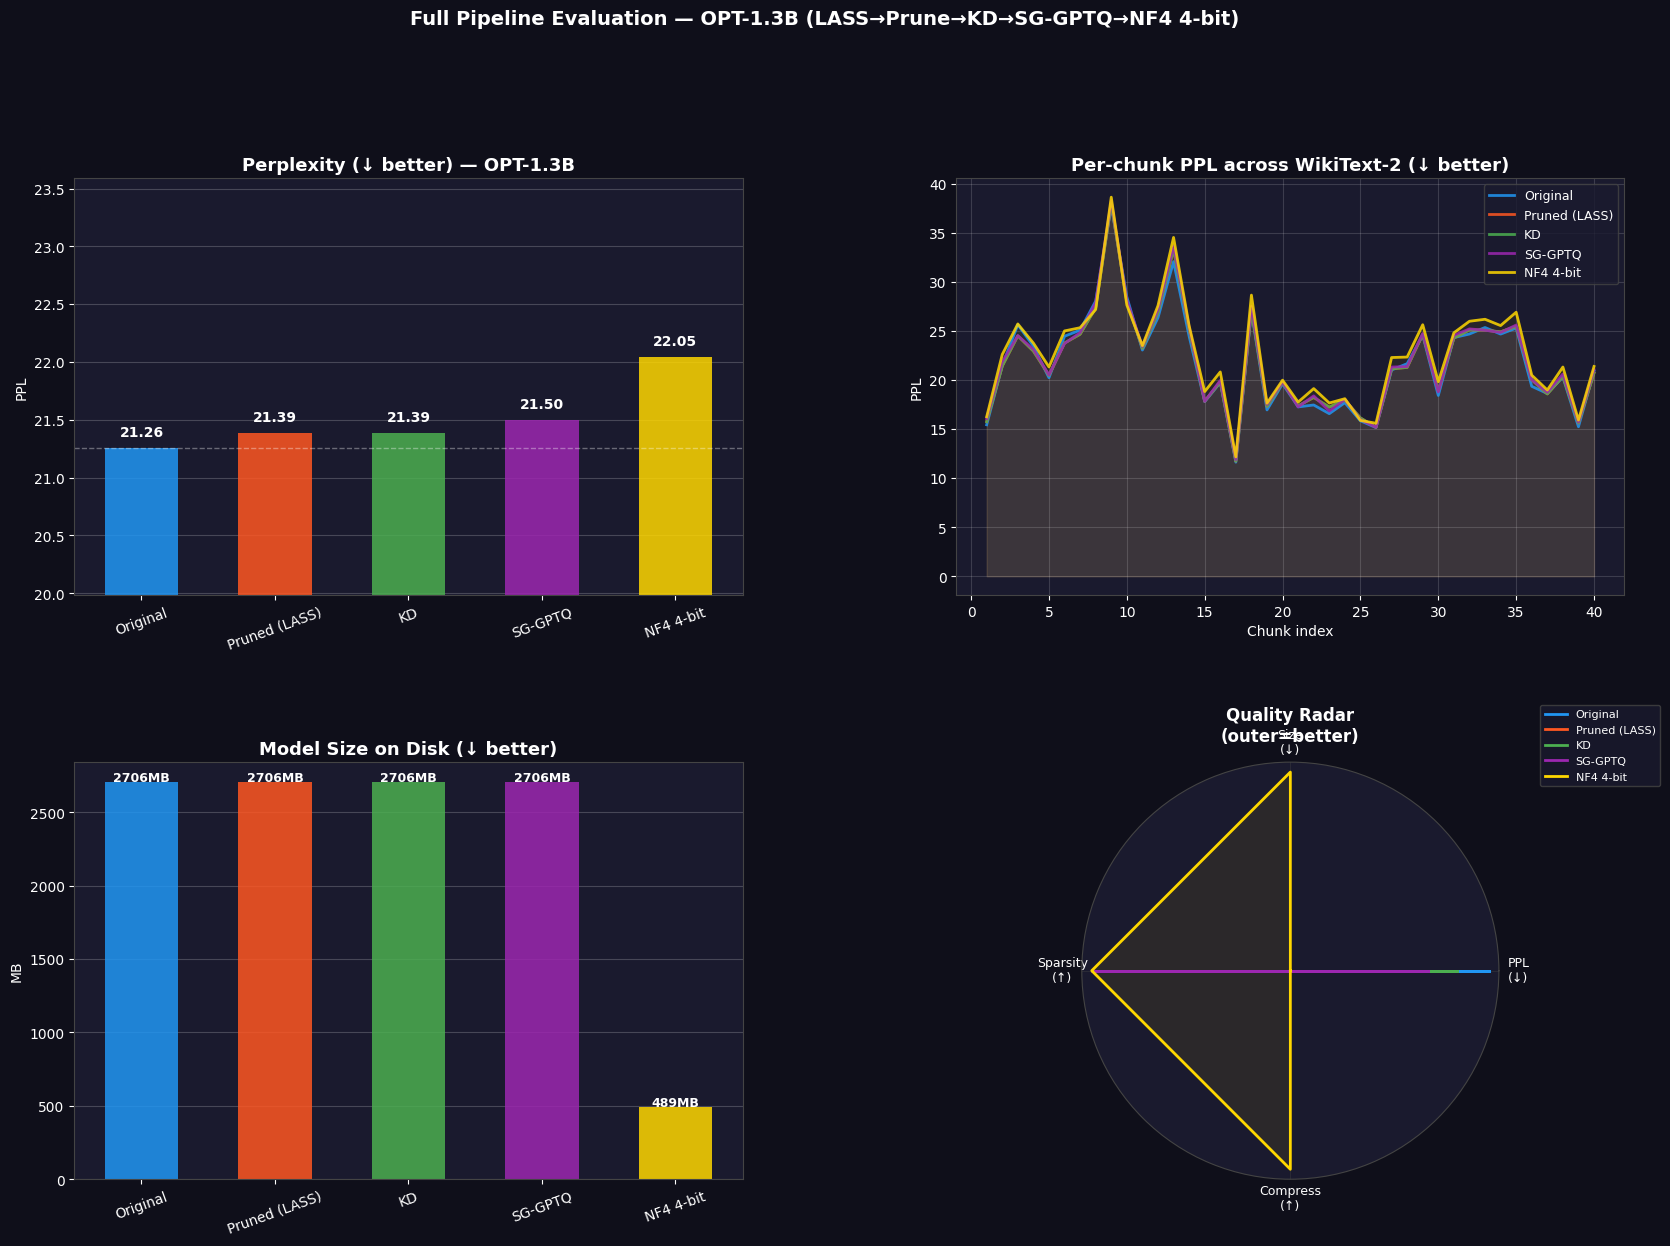

Saved: /kaggle/working/opt_eval_plots/opt_fig1_overview.png
Generation results: /kaggle/working/opt_eval_plots/opt_generation_results.txt


OPT-1.3B FINAL RESULTS
Model                       PPL      ΔPPL   Sparsity      Size   Compression
---------------------------------------------------------------------------
Original                  21.26         —      0.00%    2706MB          1.0×
Pruned (LASS)             21.39     +0.13     24.71%    2706MB          1.0×
KD                        21.39     +0.13     24.71%    2706MB          1.0×
SG-GPTQ                   21.50     +0.24     24.90%    2706MB          1.0×
NF4 4-bit                 22.05     +0.79     24.90%     489MB          5.5×

All plots → /kaggle/working/opt_eval_plots


18776

In [1]:

import os, gc, sys, math, json, torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig,
    LogitsProcessor, LogitsProcessorList
)


import os as _os
import torch as _torch_ver
import packaging.version as _pv
if _pv.parse(_torch_ver.__version__) < _pv.parse("2.6.0"):
    _os.environ["TRANSFORMERS_WEIGHTS_ONLY"] = "0"
    print(f"[compat] torch {_torch_ver.__version__} < 2.6 detected — "
          "set TRANSFORMERS_WEIGHTS_ONLY=0 to allow .bin loading")
else:
    print(f"[compat] torch {_torch_ver.__version__} >= 2.6 ✓")


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

BASE_MODEL   = "facebook/opt-1.3b"
PRUNED_MODEL = "/kaggle/working/opt_pruned_lass"
KD_MODEL     = "/kaggle/working/opt_final_sparse_kd"
SGPTQ_MODEL  = "/kaggle/working/opt_sg_gptq_model"
PLOT_DIR     = "/kaggle/working/opt_eval_plots"
os.makedirs(PLOT_DIR, exist_ok=True)


class ClampLogits(LogitsProcessor):
    def __call__(self, input_ids, scores):
        return torch.clamp(scores, -20, 20)

processors = LogitsProcessorList([ClampLogits()])


def compute_ppl_chunked_hf(model, tokenizer, dev, seqlen=512, n_chunks=40):
    model.eval()
    data = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    full_text = "\n\n".join(data["text"])
    max_tokens = getattr(model.config, "max_position_embeddings", 2048)
    enc = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=min(max_tokens * n_chunks, 100000)
    ).input_ids
    nlls, total_chunks = [], min(n_chunks, enc.shape[1] // seqlen)
    for i in range(total_chunks):
        batch = enc[:, i * seqlen:(i + 1) * seqlen].to(dev)
        with torch.no_grad():
            loss = model(batch, labels=batch).loss.float()
        nlls.append(loss * (seqlen - 1))
    return torch.exp(torch.stack(nlls).sum() / (total_chunks * (seqlen - 1))).item()


def compute_ppl_per_chunk_hf(model, tokenizer, dev, seqlen=512, n_chunks=40):
    model.eval()
    data = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    full_text = "\n\n".join(data["text"])
    max_tokens = getattr(model.config, "max_position_embeddings", 2048)
    enc = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=min(max_tokens * n_chunks, 100000)
    ).input_ids
    ppls, total_chunks = [], min(n_chunks, enc.shape[1] // seqlen)
    for i in range(total_chunks):
        batch = enc[:, i * seqlen:(i + 1) * seqlen].to(dev)
        with torch.no_grad():
            loss = model(batch, labels=batch).loss.float()
        ppls.append(torch.exp(loss).item())
    return ppls


def compute_sparsity(model):
    total, zeros = 0, 0
    for n, p in model.named_parameters():
        if "weight" in n and p.dim() >= 2:
            total += p.numel()
            zeros += (p == 0).sum().item()
    return 100.0 * zeros / total if total > 0 else 0.0


def model_size_mb(path):
    if os.path.isfile(path):
        return os.path.getsize(path) / (1024 * 1024)
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(".safetensors") or f.endswith(".bin"):
                total += os.path.getsize(os.path.join(root, f))
    return total / (1024 * 1024)


def model_size_mb_4bit(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return (total_bytes / 2) / (1024 * 1024)


def generate_hf(model, tokenizer, prompt, dev, max_new=120):
    
    model.eval()
    enc = tokenizer(prompt, return_tensors="pt").to(dev)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=max_new,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            logits_processor=processors,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = out[0][enc["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()



print("\n" + "="*65)
print("PHASE 1: HF MODELS — OPT-1.3B")
print("="*65)

hf_cfgs = [
    ("Original",      BASE_MODEL,   "#2196F3"),
    ("Pruned (LASS)", PRUNED_MODEL, "#FF5722"),
    ("KD",            KD_MODEL,     "#4CAF50"),
    ("SG-GPTQ",       SGPTQ_MODEL,  "#9C27B0"),
]

results = {}

for label, path, color in hf_cfgs:
    print(f"\n── {label} ──")
    tok = AutoTokenizer.from_pretrained(path)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        path,
        dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto"
    )
    mdl.eval()
    dev = next(mdl.parameters()).device

    sp         = compute_sparsity(mdl)
    chunk_ppls = compute_ppl_per_chunk_hf(mdl, tok, dev)
    ppl        = math.exp(np.mean([math.log(p) for p in chunk_ppls]))
    sz         = model_size_mb(path) if path != BASE_MODEL else \
                 sum(p.numel() * 2 for p in mdl.parameters()) / 1024**2

    results[label] = {
        "ppl":        round(ppl, 3),
        "sparsity":   round(sp, 2),
        "size_mb":    round(sz, 1),
        "chunk_ppls": chunk_ppls,
        "color":      color,
        "model_obj":  mdl,
        "tok":        tok,
        "dev":        dev,
    }
    print(f"  PPL={ppl:.2f}  Sparsity={sp:.2f}%  Size={sz:.0f}MB")



print("\n" + "="*65)
print("PHASE 2: NF4 4-BIT QUANTIZED MODEL")
print("="*65)

tok_4bit = AutoTokenizer.from_pretrained(SGPTQ_MODEL)
if tok_4bit.pad_token is None:
    tok_4bit.pad_token = tok_4bit.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
mdl_4bit = AutoModelForCausalLM.from_pretrained(
    SGPTQ_MODEL, quantization_config=bnb_config, device_map="auto"
)
mdl_4bit.eval()
dev_4bit = next(mdl_4bit.parameters()).device
print("4-bit model loaded ✓")

chunk_ppls_4bit = compute_ppl_per_chunk_hf(mdl_4bit, tok_4bit, dev_4bit)
ppl_4bit        = math.exp(np.mean([math.log(p) for p in chunk_ppls_4bit]))
sz_4bit         = model_size_mb_4bit(mdl_4bit)
sp_4bit         = results["SG-GPTQ"]["sparsity"]

print(f"  PPL={ppl_4bit:.2f}  Size≈{sz_4bit:.0f}MB")

results["NF4 4-bit"] = {
    "ppl":        round(ppl_4bit, 3),
    "sparsity":   sp_4bit,
    "size_mb":    round(sz_4bit, 1),
    "chunk_ppls": chunk_ppls_4bit,
    "color":      "#FFD700",
    "model_obj":  mdl_4bit,
    "tok":        tok_4bit,
    "dev":        dev_4bit,
}



print("\n" + "="*65)
print("PHASE 3: GENERATION COMPARISON")
print("="*65)

prompts = [
    "What is artificial intelligence?",
    "What is the capital of France?",
    "Who developed the theory of relativity?",
    "Explain machine learning in simple words.",
    "Explain pruning and quantization.",
    "Write a short paragraph about climate change.",
    "What is photosynthesis?",
    "What is Newton's second law?",
    "What is 2 + 2?",
    "Write a short motivational paragraph."
]

gen_results = {lbl: [] for lbl in results}
for i, prompt in enumerate(prompts, 1):
    print(f"\nQ{i}: {prompt}")
    for lbl, cfg2 in results.items():
        ans = generate_hf(cfg2["model_obj"], cfg2["tok"], prompt, cfg2["dev"])
        gen_results[lbl].append(ans)
        print(f"  [{lbl}]: {ans[:120]}{'...' if len(ans) > 120 else ''}")



labels   = list(results.keys())
orig_ppl = results["Original"]["ppl"]

print("\n\n" + "="*80)
print("       FULL PIPELINE RESULTS — OPT-1.3B")
print("="*80)
print(f"{'Model':<22} {'PPL':>8} {'ΔPPL':>9} {'Sparsity':>10} {'Size(MB)':>10} {'Compress':>10}")
print("-"*72)
for lbl in labels:
    r    = results[lbl]
    ppl_ = r["ppl"]
    dp   = f"+{ppl_-orig_ppl:.2f}" if lbl != "Original" else "    —"
    comp = f"{results['Original']['size_mb']/max(r['size_mb'],1):.1f}×" \
           if lbl != "Original" else "   1.0×"
    print(f"{lbl:<22} {ppl_:>8.2f} {dp:>9} {r['sparsity']:>9.2f}% "
          f"{r['size_mb']:>9.0f}  {comp:>10}")
print("="*80)



COLORS = [results[l]["color"] for l in labels]
ppls   = [results[l]["ppl"]     for l in labels]
sizes  = [results[l]["size_mb"] for l in labels]

fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor("#0f0f1a")
gs  = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.32)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]
for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    ax.title.set_color("white")
    for sp in ax.spines.values(): sp.set_edgecolor("#444")

ax_ppl, ax_curve, ax_size, _ = axes

bars = ax_ppl.bar(labels, ppls, color=COLORS, alpha=0.85, width=0.55, zorder=2)
ax_ppl.axhline(orig_ppl, color="white", ls="--", lw=1, alpha=0.35)
ax_ppl.set_title("Perplexity (↓ better) — OPT-1.3B", fontsize=13, fontweight="bold")
ax_ppl.set_ylabel("PPL", color="white")
ax_ppl.set_ylim(min(ppls)*0.94, max(ppls)*1.07)
ax_ppl.tick_params(axis="x", rotation=20)
ax_ppl.yaxis.label.set_color("white")
for bar, val in zip(bars, ppls):
    ax_ppl.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f"{val:.2f}", ha="center", color="white", fontsize=10, fontweight="bold")
ax_ppl.grid(axis="y", alpha=0.2, color="white")

for lbl in labels:
    cppls = results[lbl]["chunk_ppls"]
    if not cppls: continue
    xs = list(range(1, len(cppls)+1))
    ax_curve.plot(xs, cppls, color=results[lbl]["color"], lw=2, alpha=0.85, label=lbl)
    ax_curve.fill_between(xs, cppls, alpha=0.06, color=results[lbl]["color"])
ax_curve.set_title("Per-chunk PPL across WikiText-2 (↓ better)", fontsize=13, fontweight="bold")
ax_curve.set_xlabel("Chunk index", color="white")
ax_curve.set_ylabel("PPL", color="white")
ax_curve.xaxis.label.set_color("white")
ax_curve.yaxis.label.set_color("white")
ax_curve.legend(fontsize=9, labelcolor="white", facecolor="#1a1a2e", edgecolor="#444")
ax_curve.grid(alpha=0.15, color="white")

bars_size = ax_size.bar(labels, sizes, color=COLORS, alpha=0.85, width=0.55, zorder=2)
ax_size.set_title("Model Size on Disk (↓ better)", fontsize=13, fontweight="bold")
ax_size.set_ylabel("MB", color="white")
ax_size.tick_params(axis="x", rotation=20)
ax_size.yaxis.label.set_color("white")
for bar, val in zip(bars_size, sizes):
    ax_size.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
                 f"{val:.0f}MB", ha="center", color="white", fontsize=9, fontweight="bold")
ax_size.grid(axis="y", alpha=0.2, color="white")

axes[3].remove()
ax_radar = fig.add_subplot(gs[1, 1], polar=True)
ax_radar.set_facecolor("#1a1a2e")
ax_radar.spines["polar"].set_color("#444")

def norm_inv(vals):
    arr = np.array(vals, dtype=float); mn, mx = arr.min(), arr.max()
    return 1 - (arr - mn) / (mx - mn + 1e-9)
def norm_fwd(vals):
    arr = np.array(vals, dtype=float); mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

radar_lbl = ["PPL\n(↓)", "Size\n(↓)", "Sparsity\n(↑)", "Compress\n(↑)"]
raw_ppl  = [results[l]["ppl"]      for l in labels]
raw_size = [results[l]["size_mb"]  for l in labels]
raw_sp   = [results[l]["sparsity"] for l in labels]
raw_comp = [results["Original"]["size_mb"] / max(results[l]["size_mb"], 1) for l in labels]
normed   = np.stack([norm_inv(raw_ppl), norm_inv(raw_size), norm_fwd(raw_sp), norm_fwd(raw_comp)], axis=1)

N = 4; angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
for i, (lbl, color) in enumerate(zip(labels, COLORS)):
    vals = normed[i].tolist() + [normed[i][0]]
    ax_radar.plot(angles, vals, color=color, lw=2, label=lbl)
    ax_radar.fill(angles, vals, color=color, alpha=0.08)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_lbl, color="white", fontsize=9)
ax_radar.set_yticks([])
ax_radar.set_title("Quality Radar\n(outer=better)",
    fontsize=12, fontweight="bold", color="white", pad=15)
ax_radar.legend(fontsize=8, labelcolor="white", facecolor="#1a1a2e", edgecolor="#444",
                loc="upper right", bbox_to_anchor=(1.4, 1.15))
ax_radar.grid(color="#444", alpha=0.4)

fig.suptitle("Full Pipeline Evaluation — OPT-1.3B (LASS→Prune→KD→SG-GPTQ→NF4 4-bit)",
             fontsize=14, fontweight="bold", color="white", y=1.01)


import shutil, os
disk = shutil.disk_usage("/kaggle/working")
print(f"Disk free: {disk.free / 1024**3:.2f} GB")
if disk.free < 50 * 1024**2:  # less than 50 MB free
    print("Low disk space — clearing intermediate model zips...")
    for f in os.listdir("/kaggle/working"):
        if f.endswith(".zip"):
            os.remove(f"/kaggle/working/{f}")
            print(f"  Deleted {f}")

path1 = os.path.join(PLOT_DIR, "opt_fig1_overview.png")
fig.savefig(path1, dpi=80, bbox_inches="tight", facecolor=fig.get_facecolor())  # dpi 150→80
plt.show()
print(f"Saved: {path1}")



gen_path = os.path.join(PLOT_DIR, "opt_generation_results.txt")
with open(gen_path, "w") as f:
    f.write("GENERATION COMPARISON — OPT-1.3B\n" + "="*70 + "\n\n")
    for i, prompt in enumerate(prompts, 1):
        f.write(f"Q{i}: {prompt}\n")
        for lbl in gen_results:
            ans = gen_results[lbl][i-1] if i-1 < len(gen_results[lbl]) else ""
            f.write(f"\n  [{lbl}]:\n  {ans}\n")
        f.write("\n" + "-"*70 + "\n\n")
print(f"Generation results: {gen_path}")

summary = {
    "models": {
        lbl: {
            "ppl":         results[lbl]["ppl"],
            "sparsity":    results[lbl]["sparsity"],
            "size_mb":     results[lbl]["size_mb"],
            "delta_ppl":   round(results[lbl]["ppl"] - orig_ppl, 3),
            "compression": round(results["Original"]["size_mb"] /
                                 max(results[lbl]["size_mb"], 1), 2),
        }
        for lbl in labels
    }
}
with open(os.path.join(PLOT_DIR, "opt_eval_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\n\n" + "="*80)
print("OPT-1.3B FINAL RESULTS")
print("="*80)
print(f"{'Model':<22} {'PPL':>8} {'ΔPPL':>9} {'Sparsity':>10} {'Size':>9} {'Compression':>13}")
print("-"*75)
for lbl in labels:
    r = results[lbl]
    dp = f"+{r['ppl']-orig_ppl:.2f}" if lbl != "Original" else "—"
    comp = f"{results['Original']['size_mb']/max(r['size_mb'],1):.1f}×" if lbl != "Original" else "1.0×"
    print(f"{lbl:<22} {r['ppl']:>8.2f} {dp:>9} {r['sparsity']:>9.2f}% "
          f"{r['size_mb']:>7.0f}MB {comp:>13}")
print("="*80)
print(f"\nAll plots → {PLOT_DIR}")


for lbl in list(results.keys()):
    if "model_obj" in results[lbl]:
        del results[lbl]["model_obj"]
torch.cuda.empty_cache()
gc.collect()